# ISA 391 Final

Hackstreet Boys: Tim Wilcox, Daniel Woodward, Ema Hedman, Charlie Cooney, Isobel Bartels

In [ ]:
import pandas as pd
filepath = '/content/Project 3 Investor Sentiment in Social Media_BitcoinTalk_Posts.csv'

df = pd.read_csv(filepath)
df.head()

,text,date
0,"I disagree. Because first of all, he is not ju...",20211115
1,Indeed. Most of us in the restricted countries...,20211115
2,"I hope this will not sound aggressive, but som...",20211115
3,newbie always think that price always getting ...,20211115
4,This will only happened if you didn't set a st...,20211115


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
neg = open('/content/negative-words.txt', 'r').read().splitlines()

pos = open('/content/positive-words.txt', 'r').read().splitlines()

In [ ]:
pos_score = []
for line in df['text']:
  score = 0
  for word in line.split(" "):
    if word in pos:
      score = score + 1
    if word in neg:
      score = score - 1
  pos_score.append(score)
df['positivity_score'] = pos_score

df.head()

,text,date,positivity_score
0,"I disagree. Because first of all, he is not ju...",20211115,5
1,Indeed. Most of us in the restricted countries...,20211115,1
2,"I hope this will not sound aggressive, but som...",20211115,-1
3,newbie always think that price always getting ...,20211115,-4
4,This will only happened if you didn't set a st...,20211115,0


In [ ]:
%pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 7.8 MB/s eta 0:00:00


In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
# instantiating model
sia = SentimentIntensityAnalyzer()
# applying model

vader_score = []
for review in df['text']:
  vader_score.append(sia.polarity_scores(review)['compound'])
df['vader_score'] = vader_score

display(df.head())

,text,date,positivity_score,vader_score
0,"I disagree. Because first of all, he is not ju...",20211115,5,0.9656
1,Indeed. Most of us in the restricted countries...,20211115,1,0.8558
2,"I hope this will not sound aggressive, but som...",20211115,-1,-0.6159
3,newbie always think that price always getting ...,20211115,-4,-0.5423
4,This will only happened if you didn't set a st...,20211115,0,-0.7361


# Time Series Plot : Aggregate Comment Counts per Day



In [ ]:
df_time_series = df.groupby('date').size().reset_index(name='comment_count')
display(df_time_series.head())

,date,comment_count
0,20100712,12
1,20100714,2
2,20100715,2
3,20100721,1
4,20100723,5


In [ ]:
import plotly.express as px
import pandas as pd

df_time_series['date'] = pd.to_datetime(df_time_series['date'], format='%Y%m%d')

fig = px.line(df_time_series, x='date', y='comment_count',
              title='Daily Comment Counts Over Time',
              labels={'date': 'Date', 'comment_count': 'Comment Count'})

fig.update_xaxes(rangeslider_visible=True, rangeselector=dict(
    buttons=list([
        dict(count=1, label='1m', step='month', stepmode='backward'),
        dict(count=6, label='6m', step='month', stepmode='backward'),
        dict(count=1, label='YTD', step='year', stepmode='todate'),
        dict(count=1, label='1y', step='year', stepmode='backward'),
        dict(step='all')
    ])
))

fig.show()

This time-series analysis tracks daily comment volume from 2011 through 2022. The trend shows two distinct phases: a long period of inactivity followed by a sudden spike in growth. Specifically, engagement remained near zero for almost a decade before rising sharply in the last two years of the dataset.

## Sentiment Distribution Bar Chart (Positivity Score)

In [ ]:
def categorize_vader_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['vader_sentiment_category'] = df['vader_score'].apply(categorize_vader_sentiment)

def categorize_positivity_sentiment(score):
    if score > 0:
        return 'Positive'
    elif score < 0:
        return 'Negative'
    else:
        return 'Neutral'

df['positivity_sentiment_category'] = df['positivity_score'].apply(categorize_positivity_sentiment)

df.head()

,text,date,positivity_score,vader_score,vader_sentiment_category,positivity_sentiment_category
0,"I disagree. Because first of all, he is not ju...",20211115,5,0.9656,Positive,Positive
1,Indeed. Most of us in the restricted countries...,20211115,1,0.8558,Positive,Positive
2,"I hope this will not sound aggressive, but som...",20211115,-1,-0.6159,Negative,Negative
3,newbie always think that price always getting ...,20211115,-4,-0.5423,Negative,Negative
4,This will only happened if you didn't set a st...,20211115,0,-0.7361,Negative,Neutral


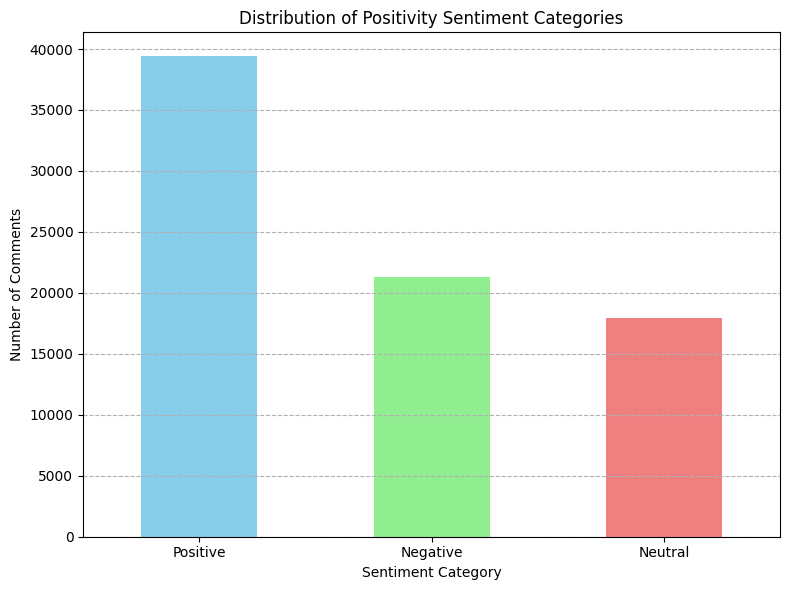

In [ ]:
import matplotlib.pyplot as plt

positivity_sentiment_counts = df['positivity_sentiment_category'].value_counts()

plt.figure(figsize=(8, 6))
positivity_sentiment_counts.plot(kind='bar', color=['skyblue', 'lightgreen', 'lightcoral'])
plt.title('Distribution of Positivity Sentiment Categories')
plt.xlabel('Sentiment Category')
plt.ylabel('Number of Comments')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

The analysis of sentiment distribution indicates a distinct positive skew, with the 'Positive' category constituting the mode of the dataset. Specifically, positive comments appear at nearly double the frequency of negative ones. This frequency data is crucial for contextualizing the average scores discussed previously; while the Normalized Score suggested a general negative trend, the raw counts confirm that the majority of individual interactions are, in fact, positive. This discrepancy implies that while negative comments are less frequent, they likely possess higher lexical intensity, which disproportionately impacts the averages in certain calculation methods.

# Comparison of Average Sentiment Scores

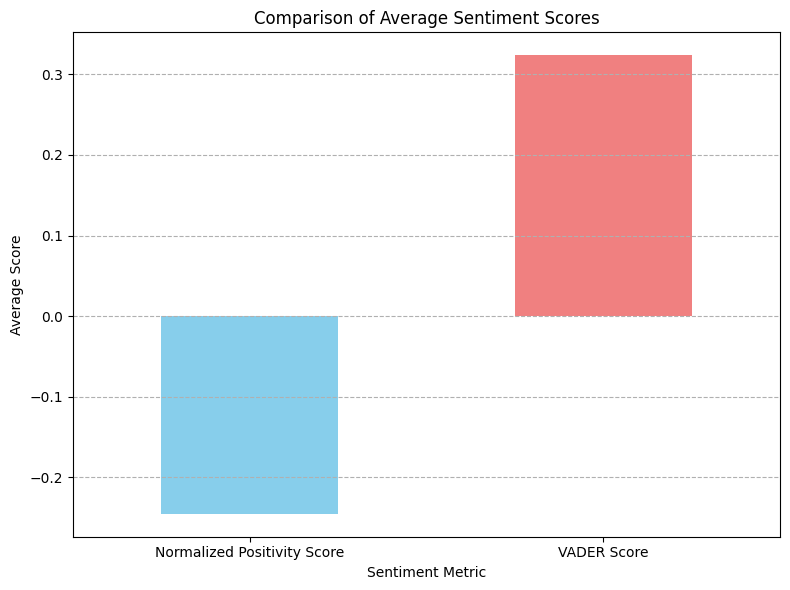

In [ ]:
import matplotlib.pyplot as plt

min_positivity = df['positivity_score'].min()
max_positivity = df['positivity_score'].max()

if (max_positivity - min_positivity) != 0:
    df['normalized_positivity_score'] = 2 * ((df['positivity_score'] - min_positivity) / (max_positivity - min_positivity)) - 1
else:
    df['normalized_positivity_score'] = 0

avg_normalized_positivity = df['normalized_positivity_score'].mean()
avg_vader_score = df['vader_score'].mean()

sentiment_averages = pd.Series({
    'Normalized Positivity Score': avg_normalized_positivity,
    'VADER Score': avg_vader_score
})

plt.figure(figsize=(8, 6))
sentiment_averages.plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title('Comparison of Average Sentiment Scores')
plt.xlabel('Sentiment Metric')
plt.ylabel('Average Score')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()


The data highlights a significant divergence based on the methodology used. While the Normalized Positivity Score suggests a negative sentiment, the VADER analysis indicates a positive trend. Given that VADER is optimized for the nuances of casual text, reviews, and social media, it likely provides a more accurate representation of the true sentiment in this dataset.